### Učitavanje i karakteristike originalnog signala

U ovoj ćeliji učitavamo snimljene podatke sa ultrazvučnog senzora iz `.csv` fajla i vršimo početnu vizuelizaciju.

**Šta predstavlja ovaj signal?**
* **Vrsta signala:** U pitanju je jednodimenzionalni (1D) vremenski diskretan signal. Na $x$-osi se nalazi indeks uzorka (koji je direktno proporcionalan vremenu, jer senzor šalje impulse u jednakim vremenskim razmacima), dok se na $y$-osi nalazi očitana udaljenost izražena u centimetrima.
* **Fizičko značenje opadajućeg trenda:** Glavni trend signala je linearno opadajući. Ovo direktno oslikava scenario iz autonomne vožnje: vozilo se kreće napred i ravnomerno se približava statičnoj prepreci (npr. drugom vozilu ili pešaku). Kako vreme prolazi, distanca između vozila i objekta postaje sve manja.
* **Parametri kretanja (distanca):**
  * Kretanje pratimo od **početne distance od 200 cm**. Ovo simulira trenutak kada je sistem detektovao prepreku na 2 metra udaljenosti i počeo da je prati.
  * Cilj je da se vozilo zaustavi na **krajnjoj distanci od 10 cm** ispred prepreke. Cilj je da ne dođe do fizičkog kontakta i sudara.

Kao što se vidi na grafiku, iako je stvarno kretanje vozila idealno linearno, izmereni podaci sa senzora to nisu, što nam jasno ukazuje na potrebu za dizajniranjem odgovarajućeg Niskopropusnog (NF) digitalnog filtra.

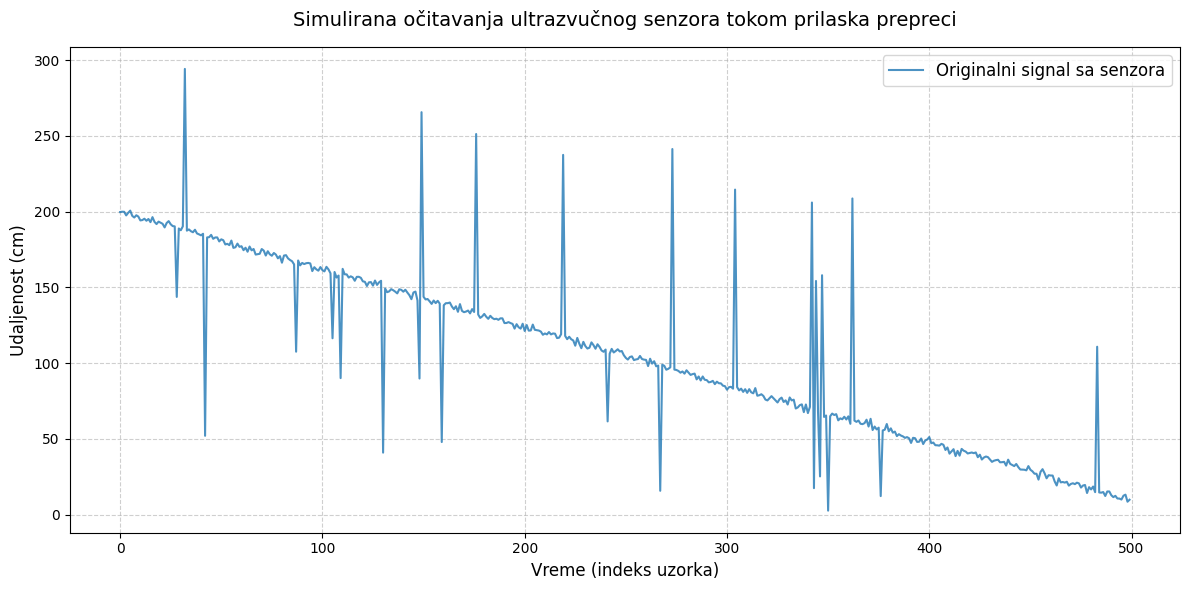

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Učitavanje podataka iz CSV fajla
df = pd.read_csv('ultrazvucni_signal.csv')

plt.figure(figsize=(12, 6))
# Plot originalnog signala sa senzora
plt.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color='tab:blue', linewidth=1.5, alpha=0.8, label='Originalni signal sa senzora')

plt.title('Simulirana očitavanja ultrazvučnog senzora tokom prilaska prepreci', fontsize=14, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Udaljenost (cm)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)


plt.tight_layout()
plt.show()

### Priroda šuma i smetnji

Kao što se može uočiti na vizuelizaciji sirovog signala, očitavanja sa ultrazvučnog senzora nisu savršena. S obzirom na to da je naš polazni signal bio **idealan** (predstavljao je savršeno linearno i kontinualno približavanje vozila prepreci), on je veštački zašumljen kako bi verno oslikao realne uslove na terenu i ponašanje pravog hardvera. 

U signalu su prisutna dva potpuno različita tipa smetnji:

1. **Kontinualni merni šum (Gausov šum):**
   * **Kako se manifestuje:** Glavni trend pada signala nije savršeno prava linija, već je blago "čupav" i nazubljen.
   * **Priroda u realnosti:** Ovo predstavlja sitne varijacije usled nesavršenosti senzora ili oscilacija napona u sistemu napajanja.
   * **Metoda simulacije:** Ovaj šum je dodat na idealni signal u vidu slučajnih vrednosti iz normalne (Gausove) raspodele, sa malom standardnom devijacijom.

2. **Impulsni šum (Ekstremni skokovi/pikovi):**
   * **Kako se manifestuje:** Oštre, vertikalne linije na grafiku koje trenutno i drastično odstupaju od stvarne udaljenosti (nerealno visoke ili nerealno niske vrednosti).
   * **Priroda u realnosti:** Ovo je najkritičnija smetnja za sisteme upravljanja. Nastaje kada se ultrazvučni talas odbije od prepreke pod lošim uglom i ne vrati se do prijemnika ili kada dođe do višestrukih refleksija od tla pre povratka u senzor. 
   * **Metoda simulacije:** Simuliran je nasumičnim odabirom izolovanih uzoraka u vremenu, kojima su zatim veštački dodate ili oduzete velike vrednosti udaljenosti.

**Zaključak:** Dok kontroler vozila može da toleriše blagi Gausov šum bez većih posledica, prisustvo impulsnog šuma (pikova) predstavlja krucijalni problem. Nerešeni pikovi bi izazvali iznenadno i nepotrebno aktiviranje sistema za kočenje. Zbog toga je neophodno primeniti odgovarajući digitalni filtar koji će ove visokofrekventne anomalije "ispeglati" pre nego što informacija stigne do algoritma za upravljanje vozilom.

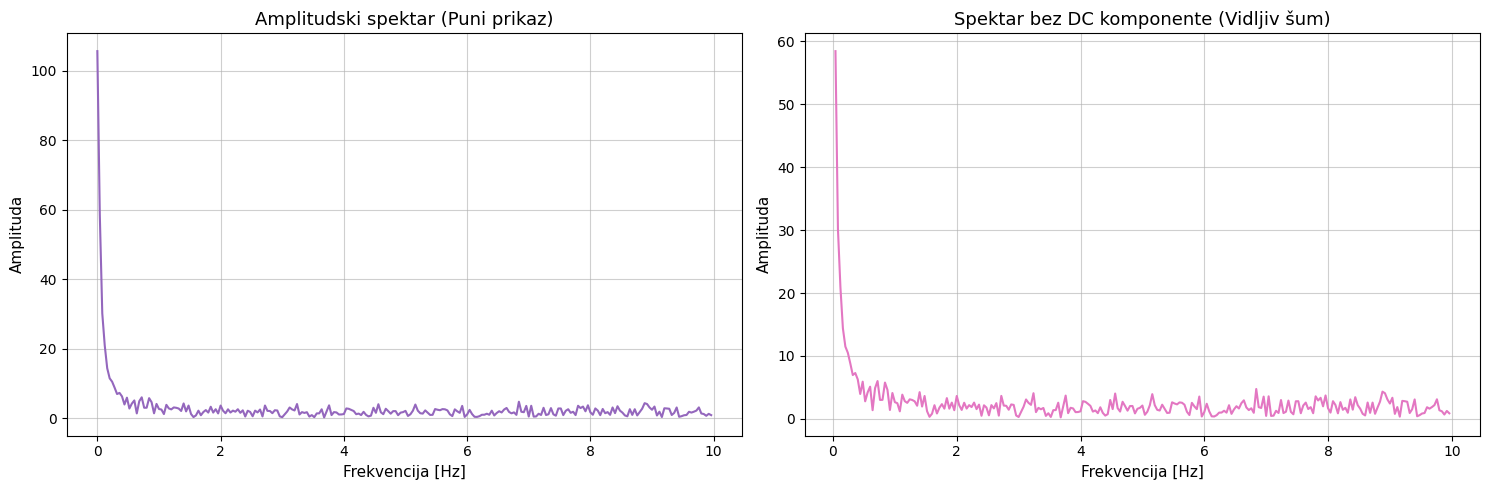

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Preuzimamo parametre iz prethodnih ćelija
fs = 20.0 # frekvencija odabiranja u Hz
signal_niz = df['Udaljenost_cm'].values
N_uzoraka = len(signal_niz)

# 1. Računanje FFT-a
yf = fft(signal_niz)

# 2. Računanje odgovarajućih frekvencija za X osu (od 0 do fs/2)
xf = fftfreq(N_uzoraka, 1/fs)[:N_uzoraka//2]

# 3. Računanje amplitudskog spektra
amplituda = 2.0 / N_uzoraka * np.abs(yf[0:N_uzoraka//2]) # Normalizacija amplitudskog spektra
amplituda[0] = amplituda[0] / 2.0 # Korekcija za DC komponentu


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ax1: Kompletan spektar
ax1.plot(xf, amplituda, color='tab:purple', linewidth=1.5)
ax1.set_title('Amplitudski spektar (Puni prikaz)', fontsize=13)
ax1.set_xlabel('Frekvencija [Hz]', fontsize=11)
ax1.set_ylabel('Amplituda', fontsize=11)
ax1.grid(alpha=0.6)

# ax2: Spektar bez DC komponente
# Ovo radimo da bismo jasnije videli kako izgleda šum
ax2.plot(xf[1:], amplituda[1:], color='tab:pink', linewidth=1.5)
ax2.set_title('Spektar bez DC komponente (Vidljiv šum)', fontsize=13)
ax2.set_xlabel('Frekvencija [Hz]', fontsize=11)
ax2.set_ylabel('Amplituda', fontsize=11)
ax2.grid(alpha=0.6)

plt.tight_layout()
plt.show()

### Spektralna analiza originalnog signala

Analizom amplitudskog spektra (FFT) originalnog, zašumljenog signala, dobijamo jasan uvid u frekvencijski sastav naših očitavanja i opravdavamo upotrebu Niskopropusnog filtra.

**1. Identifikacija dominantnih frekvencijskih komponenti**
Ubedljivo najdominantnija komponenta u spektru nalazi se na **$0\text{ Hz}$ (DC komponenta)**. Njena amplituda je izuzetno velika. Pored nje, jedine značajne komponente nalaze se u opsegu veoma niskih frekvencija (ispod $1\text{ Hz}$).

**2. Objašnjenje spektra (Korisne komponente vs. Smetnje)**
* **Korisne komponente:** Komponenta na $0\text{ Hz}$ i niske frekvencije (do cca $1\text{ Hz}$) predstavljaju korisnu informaciju. One nose podatak o stvarnoj udaljenosti i sporom, linearnom kretanju vozila ka prepreci u fizičkom svetu. Zbog tromosti vozila, fizički je nemoguće da se stvarna udaljenost menja na visokim frekvencijama.
* **Smetnje:** Sve komponente na višim frekvencijama (od $1\text{ Hz}$ do Nikvistove frekvencije od $10\text{ Hz}$) su smetnje. One ne nose nikakvu informaciju o kretanju vozila, već su posledica greške senzora.

**3. Priroda šuma u frekvencijskom domenu**
Naš originalni signal već sadrži šum, a na desnom grafiku (gde je DC komponenta uklonjena)vidimo kako se on manifestuje u spektru:
* Energija šuma je prisutna duž čitave frekvencijske ose. Ovo je direktna posledica **impulsnog šuma (pikova)**. Dirakov impuls u vremenskom domenu sadrži ravnomerno raspoređenu energiju na svim frekvencijama.
* Sitne varijacije na višim frekvencijama potiču od dodatog **Gausovog mernog šuma**, koji podiže generalni "prag šuma" u celom sistemu.

**Zaključak analize:** Pošto se korisna energija signala nalazi strogo na niskim frekvencijama, a energija smetnji proteže kroz ceo viši deo spektra, primenjujemo FIR Niskopropusni filtar sa graničnom učestanošću od $1\text{ Hz}$. Filtar će propustiti DC i niske frekvencije (kretanje vozila), a odseći sve visokofrekventne komponente (pikove i sitan šum).

### Fizička i hardverska opravdanost frekvencije odabiranja ($f_s = 20\text{ Hz}$)

U ovom projektu, signal je semplovan frekvencijom od $f_s = 20\text{ Hz}$, što znači da kontroler očitava novu vrednost udaljenosti svakih $T_s = 50\text{ ms}$ ($T_s = 1 / f_s$). Ovaj izbor je optimalan iz dva ključna razloga:

**1. Fizičko ograničenje ultrazvučnog senzora (Brzina zvuka)**
Ultrazvučni senzor meri udaljenost tako što pošalje zvučni impuls (ping) i čeka da se eho odbije od prepreke i vrati nazad. Zvuk kroz vazduh putuje brzinom od oko $340\text{ m/s}$. 
* Ako je maksimalna distanca koju naše vozilo meri npr. $4\text{ m}$, zvuk mora da pređe ukupan put od $8\text{ m}$ (do prepreke i nazad).
* Vreme potrebno za taj put je $t = s/v = 8 / 340 \approx 23.5\text{ ms}$. 
* Zbog ovog kašnjenja, **senzor fizički ne može** da radi na previsokim frekvencijama. Ako bismo novi impuls poslali pre nego što se stari eho vrati, došlo bi do preklapanja i katastrofalnih grešaka u merenju. Period od $50\text{ ms}$ (odnosno $20\text{ Hz}$) ostavlja sasvim dovoljno vremena da se i najdalji eho bezbedno vrati pre sledećeg očitavanja.


**2. Dinamika kretanja autonomnog vozila**

Za algoritam upravljanja vozilom, potrebno je da informacije stižu dovoljno brzo kako bi reakcija bila pravovremena.
* Ako bi frekvencija bila preniska (npr. $2\text{ Hz}$, osvežavanje na pola sekunde), vozilo koje se kreće brže moglo bi da udari u prepreku "na slepo" između dva očitavanja.
* Sa druge strane, frekvencija od $20\text{ Hz}$ daje kontroleru $20$ svežih informacija svake sekunde. Ovo je industrijski standard za mikrokontrolerske petlje u ovakvim sistemima, jer ne preopterećuje CPU procesiranjem, a ostavlja dovoljno rezolucije u vremenu za glatko i bezbedno upravljanje radom motora.

## Projektovanje digitalnog filtera

### 1. Definisanje zahteva filtriranja
Na osnovu prethodno sprovedene spektralne analize, definisani su sledeći zahtevi za projektovanje digitalnog filtera:
* **Tip filtera:** Niskopropusni (NF) filtar.
* **Šta se čuva:** Neophodno je sačuvati DC komponentu ($0\text{ Hz}$) i veoma niske frekvencije (do $1\text{ Hz}$).
* **Šta se uklanja:** Sve komponente iznad $1\text{ Hz}$, koje predstavljaju visokofrekventne smetnje senzora.
* **Granična frekvencija:** $f_c = 1\text{ Hz}$ (pri pretpostavljenoj frekvenciji odabiranja $f_s = 20\text{ Hz}$).

### 2. Analiza i poređenje implementiranih filtera
Kako bi se pronašlo optimalno rešenje za sistem upravljanja, implementirana su i upoređena dva različita tipa Niskopropusnih digitalnih filtera: FIR filtar (metoda prozora) i IIR Batervortov (Butterworth) filtar.

#### Filter 1: FIR NF filtar (Metoda prozora)
* **Tip i metoda:** FIR filtar niske propustljivosti, projektovan primenom Hamingovog (Hamming) prozora.
* **Red filtera:** $N-1 = 50$ (broj koeficijenata $N = 51$).
* **Granična frekvencija:** $f_c = 1\text{ Hz}$.
* **Frekvencijski odziv:**
  * *Amplitudska karakteristika:* Obezbeđuje dobro sečenje i visoko prigušenje u nepropusnom opsegu zahvaljujući Hamingovom prozoru.
  * *Fazna karakteristika:* **Strogo linearna faza**, što je ključna prednost ovog filtra.
* **Grupno kašnjenje:** Zbog linearne faze, grupno kašnjenje je konstantno za sve frekvencije i iznosi tačno $M = (N-1)/2 = 25$ odbiraka.
* **Motivacija i kompromisi:** Odabran je prvenstveno zbog linearne faze koja garantuje odsustvo faznog izobličenja — stvarni oblik krive približavanja prepreci ostaje nepromenjen. Glavni kompromis je visoka vrednost konstantnog kašnjenja (preko jedne sekunde u realnom vremenu), što usporava reakciju sistema upravljanja, kao i veća računska zahtevnost (konvolucija 51 koeficijenta).

#### Filter 2: IIR Batervortov NF filtar
* **Tip i metoda:** IIR filtar niske propustljivosti (Batervortova aproksimacija).
* **Red filtera:** $n = 4$ (znatno niži red u odnosu na FIR za slično prigušenje - 80dB/dec).
* **Granična frekvencija:** $f_c = 1\text{ Hz}$.
* **Frekvencijski odziv:**
  * *Amplitudska karakteristika:* Maksimalno ravna u propusnom opsegu, bez ikakvih talasanja koja bi veštački izazvala trzanje vozila. Oštro seče više frekvencije.
  * *Fazna karakteristika:* **Nelinearna faza**, što dovodi do različitog kašnjenja različitih frekvencijskih komponenti.
* **Grupno kašnjenje:** Nelinearno, ali u proseku drastično manje nego kod analiziranog FIR filtra, što obezbeđuje bržu reakciju vozila.
* **Motivacija i kompromisi:** Motivacija za ovaj filtar je visoka efikasnost: zahteva malo računarskih resursa mikrokontrolera i nudi brzo vreme odziva. Međutim, najveći kompromis je prisustvo povratne sprege. Kada ekstremni pik ultrazvuka (impulsni šum) uđe u filtar, povratna sprega izaziva **"zvonjenje" (dugotrajne oscilacije)** na izlazu. Sistem dugo ne može da se vrati na očitavanje prave udaljenosti.


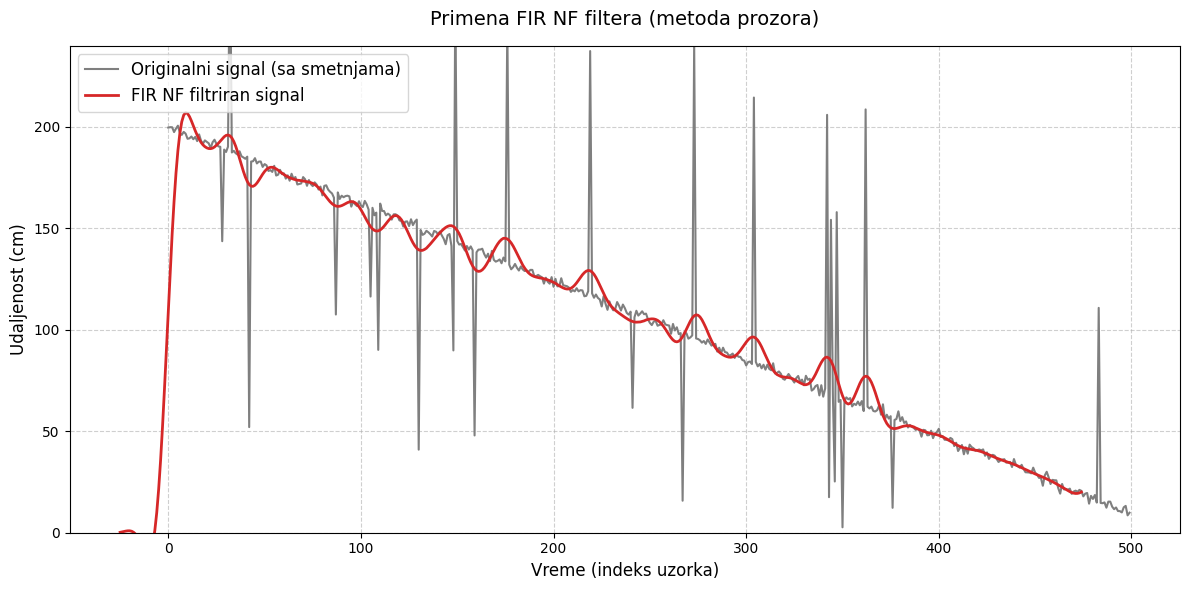

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

fs = 20.0  # (senzor čita svakih 50ms -> 20 Hz)
N = 51     # Broj koeficijenata. Bira se neparan broj (red filtera je N-1 = 50)
cutoff = 1.0 # Granična učestanost u Hz 
window_tip = 'hamming' # Standardni prozor

# 2. Projektovanje FIR filtera (metoda prozora)
h = signal.firwin(numtaps=N, cutoff=cutoff, window=window_tip, fs=fs)

# 3. Primena filtera na naš zašumljen signal
# Koristim lfilter da dobijem odziv kauzalnog sistema 
filtriran_signal = signal.lfilter(h, 1.0, df['Udaljenost_cm'])

# 4. Kašnjenje
M = (N - 1) // 2
vreme_kompenzovano = df['Vreme_indeks'] - M

plt.figure(figsize=(12, 6))

plt.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color='tab:gray', label='Originalni signal (sa smetnjama)')
plt.plot(vreme_kompenzovano, filtriran_signal, color='tab:red', linewidth=2, label='FIR NF filtriran signal')

plt.title('Primena FIR NF filtera (metoda prozora)', fontsize=14, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Udaljenost (cm)', fontsize=12)


plt.ylim(0, 240) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Analiza rezultata: Ponašanje FIR filtra u prisustvu impulsnog šuma

Kao što se može uočiti na vizuelizaciji, primenjeni FIR Niskopropusni filtar uspešno eliminiše sitni, visokofrekventni merni šum i zadržava tačan oblik glavnog trenda (zahvaljujući osobini linearne faze). Međutim, na mestima gde se u sirovom signalu nalaze ekstremni pikovi, odziv filtra je "povučen" nagore ili nadole u pravcu tog pika, stvarajući blago talasanje.

Ova pojava je očekivana i posledica je same prirode ovog filtra. Postoje dva glavna razloga zašto odabrani filtar ne može u potpunosti ispeglati ovakav šum:

**1. Linearna priroda filtra (Problem konvolucije)**
FIR filtri su **linearni filtri**. Matematički, svaki novi odbirak na izlazu filtra računa se kao konvolucija prethodnih $N$ uzoraka ulaznog signala koji se nalaze u "prozoru" filtra. 
Kada jedna ekstremno velika vrednost (pik) uđe u taj prozor, ona se množi sa koeficijentima filtra i veštački podiže (ili spušta) ukupnu sumu. Taj jedan "pokvaren" podatak će uticati na izlazni signal sve dok potpuno ne izađe iz prozora filtra.

**2. Energetski spektar impulsnog šuma**
Nagli, oštri pik u vremenskom domenu (sličan Dirakovom impulsu) sadrži komponente na **svim frekvencijama**. Iako Niskopropusni filtar uspešno odseca visoke frekvencije tog pika, on mora da propusti njegove niskofrekventne komponente. Te propuštene niske frekvencije ekstremnog pika se na grafiku manifestuju upravo kao ovaj preostali, razvučeni "brežuljak" na crvenoj liniji.

**Zaključak:**
Iako FIR filtar ne može savršeno eliminisati impulsni šum kao što bi to uradili **nelinearni** filtri (npr. medijanski filtar), on ipak obavlja ključan zadatak za bezbednost vozila. Ekstremno oštre, skokovite promene udaljenosti su **ublažene i razvučene u vremenu**. Ovo sprečava kontrolni sistem autonomnog vozila da reaguje panično (naglo kočenje) i omogućava mu da zadrži stabilnost upravljanja.

### Amplitudska i frekvencijaska analiza filtra

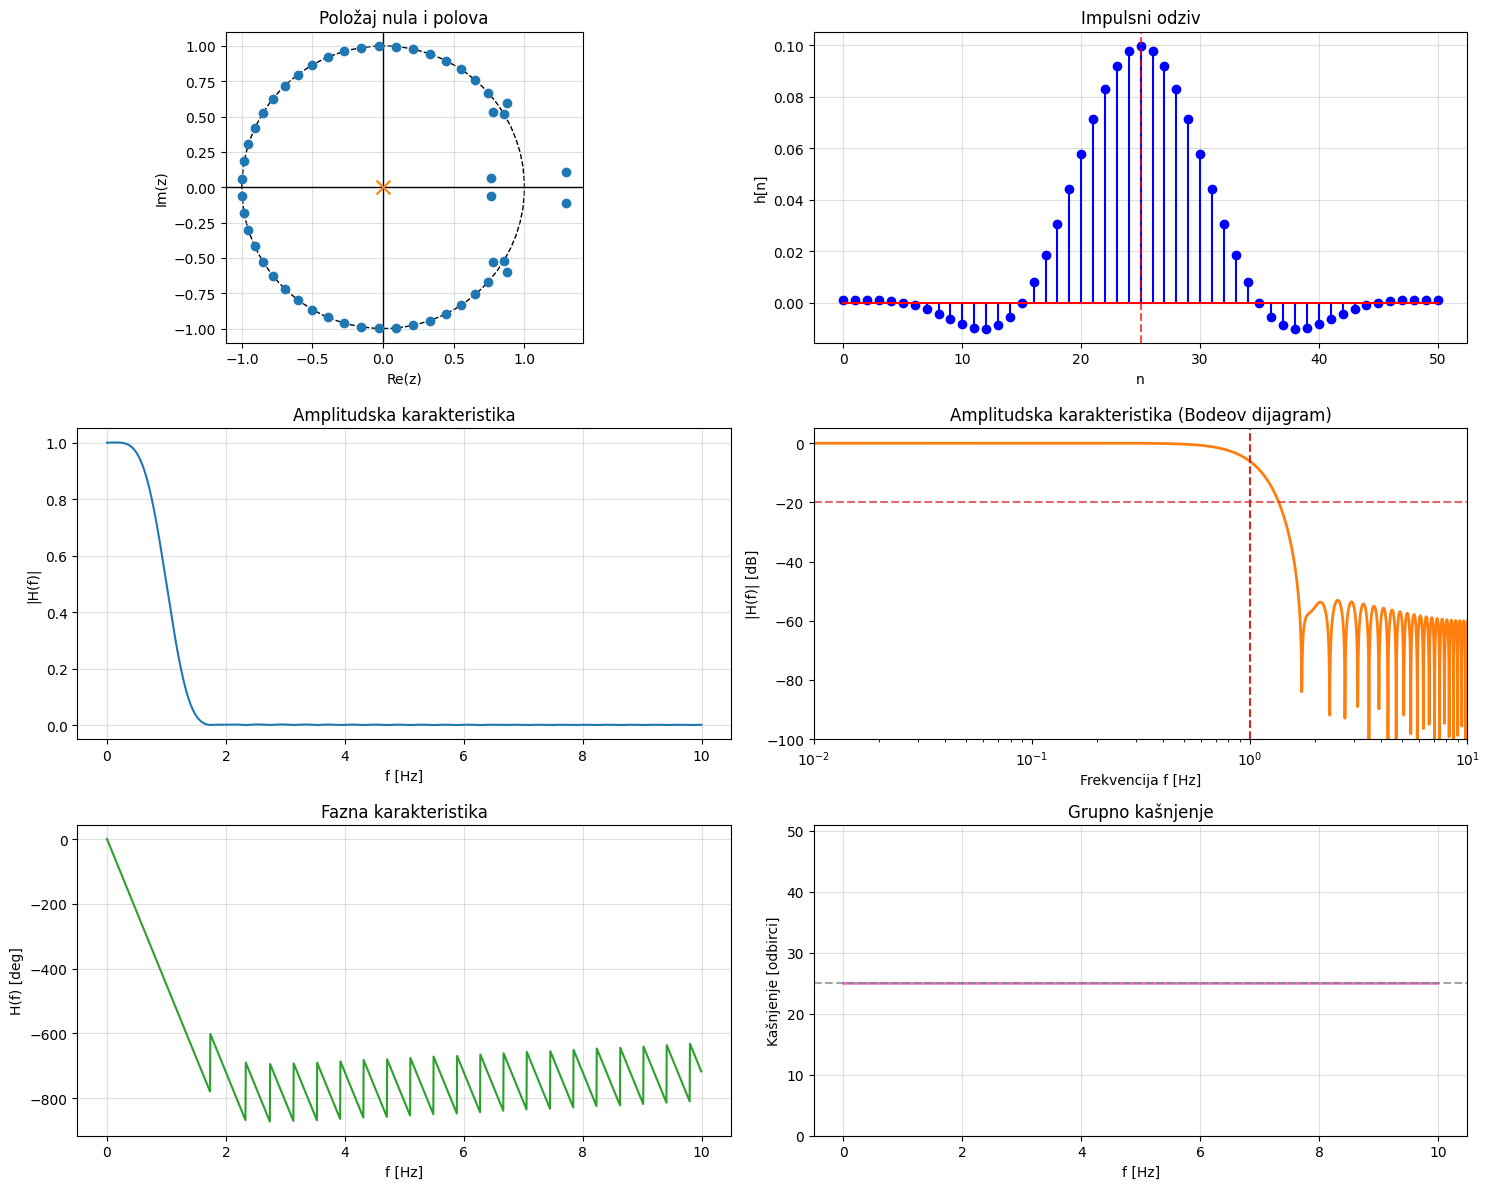

In [10]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 1. Parametri filtera 
fs = 20.0    # Frekvencija odabiranja (Hz)
N = 51       # Broj koeficijenata
cutoff = 1.0 # Granična učestanost (Hz)
h = signal.firwin(N, cutoff, window='hamming', fs=fs)


fig, axs = plt.subplots(3, 2, figsize=(15, 12))
axs = axs.flatten() # axes [0][0] -> axs[0]

# 2. Položaj nula i polova 
nule = np.roots(h)

jedinicni_krug = Circle((0,0), 1, color='black', fill=False, linestyle='--')
axs[0].add_patch(jedinicni_krug)
axs[0].axvline(0, color='black', lw=1)
axs[0].axhline(0, color='black', lw=1)

axs[0].scatter(np.real(nule), np.imag(nule), marker='o', color='tab:blue', zorder=3)
axs[0].scatter(0, 0, marker='x', color='tab:orange', s=100, zorder=3) 

axs[0].set_title('Položaj nula i polova')
axs[0].set_xlabel('Re(z)')
axs[0].set_ylabel('Im(z)')
axs[0].grid(True, alpha=0.4)
axs[0].set_aspect('equal')

# 3. Impulsni odziv h[n] 
n_osa = np.arange(N)
axs[1].stem(n_osa, h, basefmt="r-", linefmt="b-", markerfmt="bo")

M = (N - 1) / 2
axs[1].axvline(M, color='r', linestyle='--', alpha=0.7) 

axs[1].set_title('Impulsni odziv')
axs[1].set_xlabel('n')
axs[1].set_ylabel('h[n]')
axs[1].grid(True, alpha=0.4)

# Frekvencijski odziv
w, H = signal.freqz(h, 1, worN=2048, fs=fs)

# Amplitudska karakteristika 
axs[2].plot(w, np.abs(H), color='tab:blue') 
axs[2].set_title('Amplitudska karakteristika')
axs[2].set_xlabel('f [Hz]')
axs[2].set_ylabel('|H(f)|')
axs[2].grid(True, alpha=0.4)

# Amplitudska karakteristika (u decibelima - dB) 
H_dB = 20 * np.log10(np.abs(H) + 1e-12) 

axs[3].semilogx(w, H_dB, color='tab:orange', linewidth=2) 
axs[3].axvline(cutoff, color='tab:red', linestyle='--', label='Granična f') 
axs[3].axhline(-20, color='tab:red', linestyle='--', alpha=0.7) 

axs[3].set_title('Amplitudska karakteristika (Bodeov dijagram)')
axs[3].set_xlabel('Frekvencija f [Hz]')
axs[3].set_ylabel('|H(f)| [dB]')
axs[3].set_xlim(0.01, fs/2) 
axs[3].set_ylim(-100, 5) 

# Fazna karakteristika 
faza = np.unwrap(np.angle(H)) * (180 / np.pi) 

axs[4].plot(w, faza, color='tab:green') 
axs[4].set_title('Fazna karakteristika')
axs[4].set_xlabel('f [Hz]')
axs[4].set_ylabel('H(f) [deg]')
axs[4].grid(True, alpha=0.4)

# Grupno kašnjenje (Group Delay) 
w_gd, gd = signal.group_delay((h, 1), w=2048, fs=fs)

axs[5].plot(w_gd, gd, color='tab:pink', linewidth=2) 
axs[5].set_title('Grupno kašnjenje')
axs[5].set_xlabel('f [Hz]')
axs[5].set_ylabel('Kašnjenje [odbirci]')
axs[5].set_ylim(0, N)
axs[5].axhline(M, color='gray', linestyle='--', alpha=0.7)
axs[5].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Analiza karakteristika dizajniranog FIR filtra

Prikazani grafici potvrđuju da dizajnirani Niskopropusni FIR filtar ispunjava zahteve za obradu senzorskog signala:

* **Položaj nula i polova:** Svi polovi se nalaze u koordinatnom početku, što matematički garantuje da je filtar **bezuslovno stabilan** 
* **Impulsni odziv:** Vidljiva je simetrija oko središnjeg odbirka. Ova simetrija je ključna jer je ona preduslov za postizanje linearne faze.
* **Amplitudska karakteristika:** Filtar propušta frekvencije do granične učestanosti (1 Hz), dok više frekvencije značajno oslabljuje. Logaritamski prikaz (dB) pokazuje da primena Hamingovog prozora obezbeđuje odlično prigušenje u nepropusnom opsegu, efikasno gušeći komponente impulsnog šuma.
* **Fazna karakteristika:** Faza strogo linearno opada. Linearna faza garantuje da **neće doći do faznog izobličenja**. Sve komponente korisnog signala kasne za identično vreme, čime originalni oblik krive prilaska prepreci ostaje očuvan.

### Implementacija IIR Batervortovog (Butterworth) NF filtra

Kao alternativno rešenje, projektovan je IIR Niskopropusni filtar korišćenjem Batervortove aproksimacije. Cilj je ispitati da li filter sa povratnom spregom (koji je računarski manje zahtevan) može adekvatno da odgovori na zahteve filtriranja impulsnog šuma.

Za ovaj dizajn izabran je **red filtra $n=4$**. Batervortov filtar ovog reda obezbeđuje dovoljno strm prelazni opseg (slabljenje od $80\text{ dB/dekadi}$) uz zadržavanje maksimalno ravne amplitudske karakteristike u propusnom opsegu. Granična učestanost ostaje ista ($f_c = 1\text{ Hz}$).

Sledeći kod generiše i vizualizuje osnovne karakteristike ovog filtra u vremenskom, prostornom i frekvencijskom domenu, što će nam omogućiti direktno poređenje sa prethodno dizajniranim FIR filtrom.

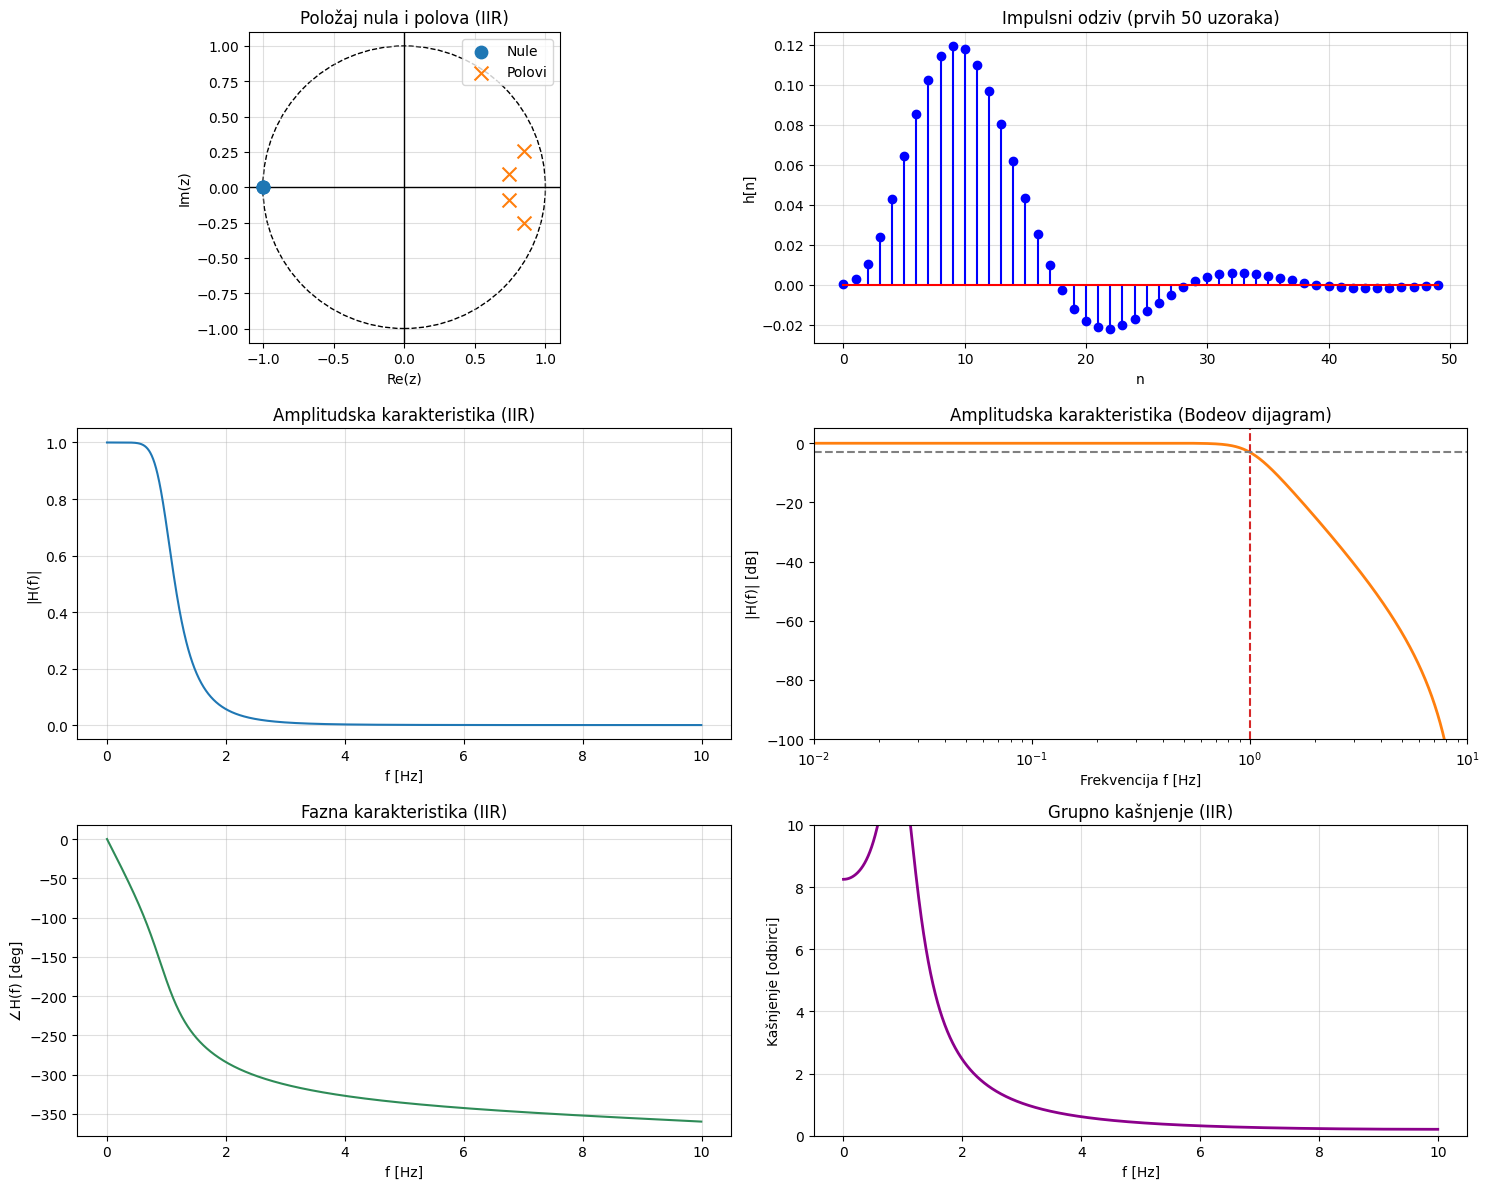

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Parametri filtera
fs = 20.0     # Frekvencija odabiranja (Hz)
cutoff = 1.0  # Granična učestanost (Hz)
red_iir = 4   # Red IIR Batervortovog filtra  
# Ako previse povećam, zvonjenje ce biti veće, ako previše smanjim zvonjenje će biti manje ali će i filter lošije prigušiti šum

# Funkcija butter vraća koeficijente polinoma brojioca (b) i imenioca (a)
b, a = signal.butter(red_iir, cutoff, btype='low', fs=fs)
# b su koef. koji mnoze ulaz, a su koef. povratne sprege


fig, axs = plt.subplots(3, 2, figsize=(15, 12))
axs = axs.flatten()

# Položaj nula i polova
# Koristimo tf2zpk (Transfer Function to Zero-Pole-Gain) da dobijemo polove i nule
z, p, k_gain = signal.tf2zpk(b, a)

jedinicni_krug = Circle((0,0), 1, color='black', fill=False, linestyle='--')
axs[0].add_patch(jedinicni_krug)
axs[0].axvline(0, color='black', lw=1)
axs[0].axhline(0, color='black', lw=1)

axs[0].scatter(np.real(z), np.imag(z), marker='o', color='tab:blue', s=80, label='Nule', zorder=3)
axs[0].scatter(np.real(p), np.imag(p), marker='x', color='tab:orange', s=100, label='Polovi', zorder=3) 

axs[0].set_title('Položaj nula i polova (IIR)')
axs[0].set_xlabel('Re(z)')
axs[0].set_ylabel('Im(z)')
axs[0].legend()
axs[0].grid(True, alpha=0.4)
axs[0].set_aspect('equal')

# Impulsni odziv h[n]
# Za IIR, impulsni odziv je teorijski beskonačan, pa računamo prvih 50 odbiraka
N_impuls = 50
impuls = np.zeros(N_impuls)
impuls[0] = 1.0 # Dirakov impuls
h_iir = signal.lfilter(b, a, impuls)

n_osa = np.arange(N_impuls)
axs[1].stem(n_osa, h_iir, basefmt="r-", linefmt="b-", markerfmt="bo")

axs[1].set_title('Impulsni odziv (prvih 50 uzoraka)')
axs[1].set_xlabel('n')
axs[1].set_ylabel('h[n]')
axs[1].grid(True, alpha=0.4)

# Izračunavanje frekvencijskog odziva
w_iir, H_iir = signal.freqz(b, a, worN=2048, fs=fs)

# 4. Amplitudska karakteristika (Linearna osa)
axs[2].plot(w_iir, np.abs(H_iir), color='tab:blue') 
axs[2].set_title('Amplitudska karakteristika (IIR)')
axs[2].set_xlabel('f [Hz]')
axs[2].set_ylabel('|H(f)|')
axs[2].grid(True, alpha=0.4)

# 5. Amplitudska karakteristika (u decibelima - dB)
H_iir_dB = 20 * np.log10(np.abs(H_iir) + 1e-12) 

axs[3].semilogx(w_iir, H_iir_dB, color='tab:orange', linewidth=2) 
axs[3].axvline(cutoff, color='tab:red', linestyle='--', label='Granična f') 
axs[3].axhline(-3, color='gray', linestyle='--', label='-3 dB (Pad)')

axs[3].set_title('Amplitudska karakteristika (Bodeov dijagram)')
axs[3].set_xlabel('Frekvencija f [Hz]')
axs[3].set_ylabel('|H(f)| [dB]')

axs[3].set_xlim(0.01, fs/2) 
axs[3].set_ylim(-100, 5)

# 6. Fazna karakteristika 
faza_iir = np.unwrap(np.angle(H_iir)) * (180 / np.pi) 

axs[4].plot(w_iir, faza_iir, color='tab:green') 
axs[4].set_title('Fazna karakteristika (IIR)')
axs[4].set_xlabel('f [Hz]')
axs[4].set_ylabel('∠H(f) [deg]')
axs[4].grid(True, alpha=0.4)

# 7. Grupno kašnjenje (Group Delay)
w_gd_iir, gd_iir = signal.group_delay((b, a), w=2048, fs=fs)

axs[5].plot(w_gd_iir, gd_iir, color='tab:purple', linewidth=2) 
axs[5].set_title('Grupno kašnjenje (IIR)')
axs[5].set_xlabel('f [Hz]')
axs[5].set_ylabel('Kašnjenje [odbirci]')

axs[5].set_ylim(0, 10)
axs[5].grid(True, alpha=0.4)


plt.tight_layout()
plt.show()

### Poređenje FIR NF filtra i IIR Batervortovog NF filtra

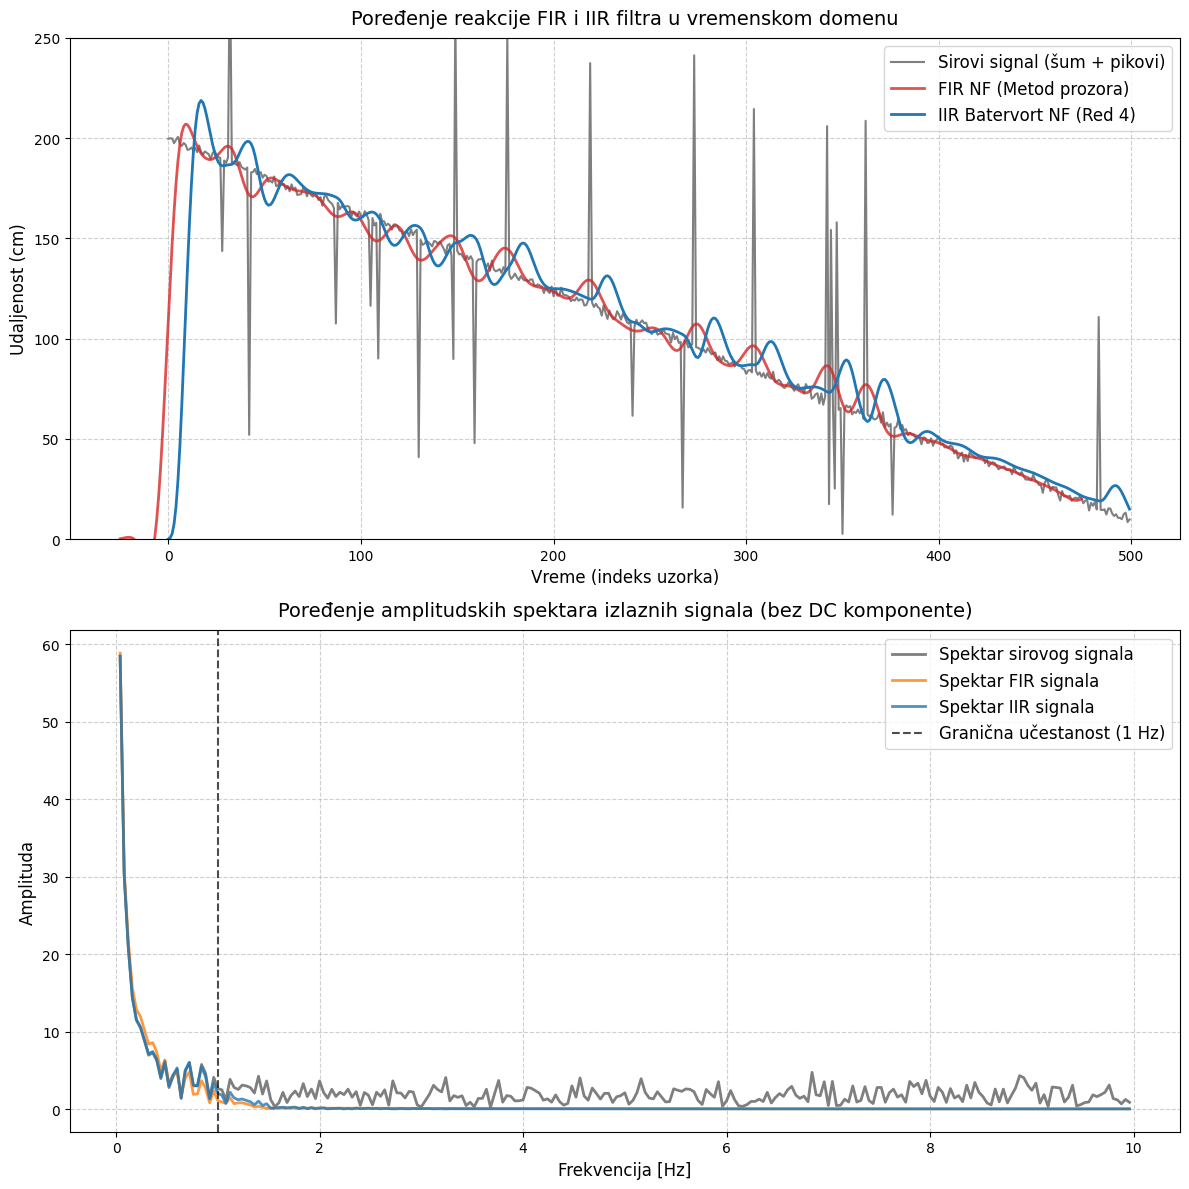

In [14]:
import scipy.signal as signal
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# --- 1. Projektovanje i primena IIR Batervortovog NF filtra ---
fs = 20.0 
cutoff = 1.0 # Granična učestanost (Hz)
red_iir = 4  # Kompromis između prigušenja šuma i "zvonjenja"

b, a = signal.butter(red_iir, cutoff, btype='low', fs=fs)

# Primena IIR filtra na originalni signal
iir_filtriran = signal.lfilter(b, a, df['Udaljenost_cm'])

# 2. Računanje FFT spektra za sva tri signala
N_uzoraka = len(df['Udaljenost_cm'])
xf = fftfreq(N_uzoraka, 1/fs)[:N_uzoraka//2]

# FFT originalnog signala
yf_raw = fft(df['Udaljenost_cm'].values)
amp_raw = 2.0 / N_uzoraka * np.abs(yf_raw[0:N_uzoraka//2])

# FFT FIR filtriranog signala
yf_fir = fft(filtriran_signal)
amp_fir = 2.0 / N_uzoraka * np.abs(yf_fir[0:N_uzoraka//2])

# FFT IIR filtriranog signala
yf_iir = fft(iir_filtriran)
amp_iir = 2.0 / N_uzoraka * np.abs(yf_iir[0:N_uzoraka//2])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# GRAFIK 1: Vremenski domen 
ax1.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color='tab:gray', label='Sirovi signal (šum + pikovi)')
ax1.plot(vreme_kompenzovano, filtriran_signal, color='tab:red', linewidth=2, alpha=0.8, label='FIR NF (Metod prozora)')
ax1.plot(df['Vreme_indeks'], iir_filtriran, color='tab:blue', linewidth=2, label=f'IIR Batervort NF (Red {red_iir})')

ax1.set_title('Poređenje reakcije FIR i IIR filtra u vremenskom domenu', fontsize=14, pad=10)
ax1.set_xlabel('Vreme (indeks uzorka)', fontsize=12)
ax1.set_ylabel('Udaljenost (cm)', fontsize=12)
ax1.set_ylim(0, 250) 
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# GRAFIK 2: Frekvencijski domen (Amplitudski spektar)

ax2.plot(xf[1:], amp_raw[1:], color='tab:gray', linewidth=2, label='Spektar sirovog signala')
ax2.plot(xf[1:], amp_fir[1:], color='tab:orange', linewidth=2, alpha=0.8, label='Spektar FIR signala')
ax2.plot(xf[1:], amp_iir[1:], color='tab:blue', linewidth=2, alpha=0.8, label='Spektar IIR signala')


ax2.axvline(cutoff, color='black', linestyle='--', alpha=0.7, label='Granična učestanost (1 Hz)')

ax2.set_title('Poređenje amplitudskih spektara izlaznih signala (bez DC komponente)', fontsize=14, pad=10)
ax2.set_xlabel('Frekvencija [Hz]', fontsize=12)
ax2.set_ylabel('Amplituda', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Analiza spektra izlaznih signala

Prikaz frekvencijskog domena nam daje ključan uvid u to kako su digitalni filtri modifikovali signal sa senzora. Sa donjeg grafika (gde je DC komponenta  izostavljena radi preglednosti) možemo izvesti sledeće zaključke:

1. **Efikasnost prigušenja:** Spektar sirovog signala (siva linija) pokazuje prisustvo energije šuma duž čitavog frekvencijskog opsega sve do $10\text{ Hz}$. Oba primenjena filtra — i FIR (crvena) i IIR (plava) — uspešno obavljaju osnovni zadatak. Sva energija iznad granične učestanosti od $1\text{ Hz}$ je drastično oslabljena i prigušena blizu nule.
2. **Zašto onda signal u vremenu i dalje ima smetnje?** Zato što impulsni šum, osim visokih, poseduje i **niskofrekventne komponente**. Na grafiku se jasno vidi da su amplitude na frekvencijama ispod $1\text{ Hz}$ ostale netaknute. Upravo te propuštene, niske frekvencije ekstremnih pikova stvaraju "razmazane" brežuljke i "zvonjenje" u vremenskom domenu.


### Konačan izbor filtera : FIR NF filtar (Metoda prozora).

**Obrazloženje:**
Iako IIR Batervortov filtar nudi brže vreme odziva i manju računarsku zahtevnost, njegova reakcija na impulsni šum (koji je specifičan i veoma čest kod HC-SR04 ultrazvučnih senzora) je neprihvatljiva za autonomno vozilo. Oscilacije ("zvonjenje") koje IIR filtar generiše nakon svakog lažnog pika trajale bi predugo i sistem upravljanja bi dobijao netačne podatke o udaljenosti u dužem vremenskom intervalu.

Sa druge strane, **FIR filtar**, zahvaljujući nedostatku povratne sprege i strogo linearnoj fazi, čuva oblik signala i brzo se oporavlja nakon prolaska pika kroz njegov "prozor" dužine 51 odbirak. Preostalo talasanje je kratkotrajno i lakše se toleriše. Dodatno, konstantno grupno kašnjenje koje FIR unosi, iako veliko, je predvidivo i može se kompenzovati u naprednijim algoritmima upravljanja, čime se osigurava stabilnost i bezbednost vozila pri prilasku prepreci.

### ZAKLJUČAK: ZAŠTO LINEARNI FILTRI (FIR I IIR) NE MOGU SAVRŠENO ISPEGLATI IMPULSNI ŠUM?

Oba implementirana filtra pripadaju klasi linearnih vremenski invarijantnih (LTI) sistema i zbog toga imaju isto matematičko ograničenje kada je u pitanju impulsni šum (ekstremni pikovi senzora):

1. **PROBLEM KONVOLUCIJE:** Linearni filtri računaju novi izlazni odbirak kao težinsku sumu (konvoluciju) ulaznih odbiraka. Kada nerealno veliki pik uđe u tu sumu, on je matematički drastično menja. Linearni filtar nema predviđenu "logiku" da prepozna anomaliju i da je prosto ignoriše. Umesto toga, on tu ogromnu vrednost mora da obradi i tako je "razmazuje" (kod FIR filtra) ili joj produžava trajanje kroz povratnu spregu (kod IIR filtra) na sve naredne odbirke, sve dok pik potpuno ne izađe iz memorije filtra.

2. **FREKVENCIJSKI PARADOKS IMPULSA:** Oštar pik (nalik dirakovom impulsu) sadrži energiju na apsolutno svim frekvencijama. Naš niskopropusni filtar uspešno odseca visoke frekvencije tog pika (čime mu uklanja oštrinu), ali matematički mora da propusti njegove niskofrekventne komponente. Te propuštene niske frekvencije se u vremenskom domenu manifestuju upravo kao ona preostala, široka izbočina ili "zvonjenje" na isfiltriranoj krivoj.

---

**Sledeći koraci (Sveska 2):**
Da bismo uspešno i u potpunosti eliminisali lažna očitavanja ultrazvučnog senzora i dobili pouzdan signal za autonomnu vožnju, moramo napustiti domen linearnih sistema. U narednoj Jupyter svesci implementiraćemo **Medijanski filtar (Median filter)** — nelinearni filtar specijalizovan za detekciju i potpuno brisanje impulsnog šuma, nakon čega ćemo preostali sitni merni šum dodatno uglačati **Filtrom pokretnog proseka (Moving Average)**.